In [1]:
# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
import csv
import pandas as pd
from collections import Counter
from sklearn.metrics import normalized_mutual_info_score
from sklearn.cluster import MiniBatchKMeans
import skfuzzy as fuzz

In [2]:
# Step 2: Load my data
def labelmaker(events, e_density, noise, filename = None, folder = None): 
    '''creates labels based on my naming convention for different files, keeps it consistent and easy'''
    if folder: 
        folder = folder + '/'

    if filename: 
        datafile = str(filename) 
    else: 
        datafile = str(events) + 'ev_n' + str(noise) + '_es' + str(int(e_density*100))    

    labelfile = 'labels_' + datafile + '.csv'
    sourcefile = 'sources_' + datafile + '.csv'
    ai_labelfile = datafile + '_AIlabels' + '.csv'
    centroidfile = datafile + '_centroids' + '.csv'
    datafile = datafile + '.csv'

    if folder: 
        datafile = folder + datafile 
        centroidfile = folder + centroidfile 
        ai_labelfile = folder + ai_labelfile 
        labelfile = folder + labelfile 
        sourcefile = folder + sourcefile 

    
    return datafile, labelfile, sourcefile, ai_labelfile, centroidfile


def pull(datafile, labelfile, sourcefile): 
    columns = ['x [px]', 'y [px]', 't [s]', 't_relToExtTrigger [s]']
    
    dataread = pd.read_csv(datafile) 
    all_data = np.array(dataread[columns])
    data = all_data[:,:3]
    
    labelread = pd.read_csv(labelfile)
    labels = np.array(labelread['labels'])
    
    sourceread = pd.read_csv(sourcefile) 
    all_sources = np.array(sourceread[columns])
    sources = all_sources[:,:3]

    return data, labels, sources

In [101]:
datafile, labelfile, sourcefile, ai_labelfile, centroidfile = labelmaker(1000, 0.25, 0, folder = 'big_datasets/formatted_for_empir')
data, labels, sources = pull(datafile, labelfile, sourcefile)
data_T = data.T

In [114]:
# Step 3: Establish Parameters 
c = 1000
fuzziness_param=2.0
tol = 0.0001
max_iters=500

In [115]:
ai_centroids, fuzzy_membership, initial_membership, distance_to_centroid, obj_func_vals, final_its, overlap_measure = fuzz.cluster.cmeans(
    data_T, 
    c=c, 
    m=fuzziness_param, 
    error=tol, 
    maxiter=max_iters
)

ai_labels = np.argmax(fuzzy_membership, axis=0)
nmi = normalized_mutual_info_score(labels, ai_labels)
print(nmi)

0.6177738928654658


<Figure size 640x480 with 0 Axes>

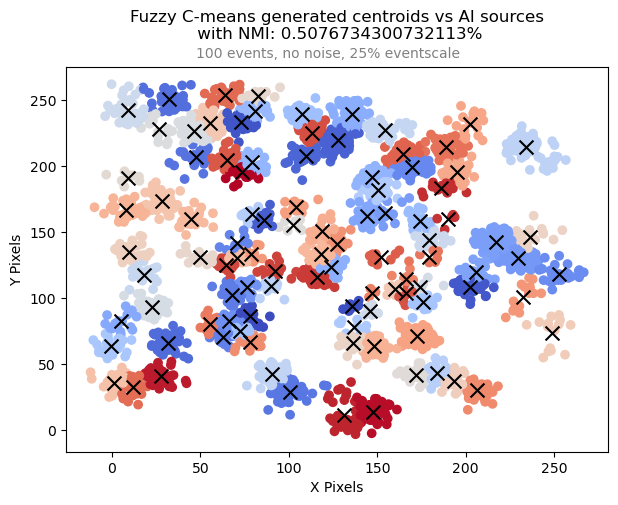

In [ ]:

plt.figure()
plt.figure(figsize=(7, 5))
plt.scatter(data[:,0], data[:,1], c=ai_labels, cmap='coolwarm')
plt.scatter(ai_centroids[:,0], ai_centroids[:,1], marker='x', s=100, c='black')
plt.title(f"Fuzzy C-means generated centroids vs AI sources\n with NMI: {nmi}%", y = 1.05)
plt.suptitle("100 events, no noise, 25% eventscale", y=0.92, fontsize = 10, color = 'gray')
plt.ylabel('Y Pixels')
plt.xlabel('X Pixels')
plt.show()

<Figure size 640x480 with 0 Axes>

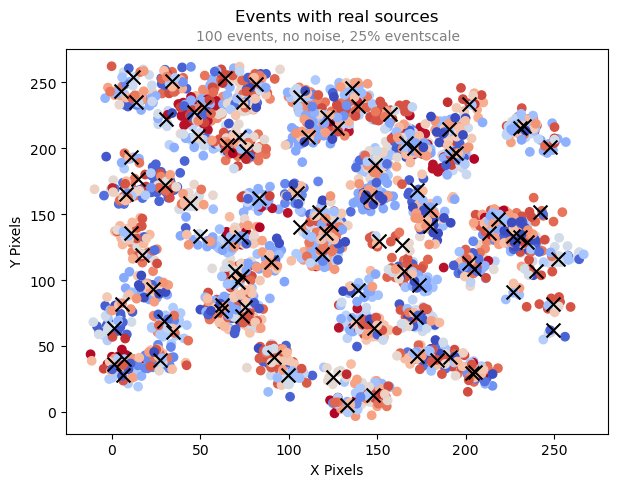

In [7]:
plt.figure()
plt.figure(figsize=(7, 5))
plt.scatter(data[:,0], data[:,1], c=labels, cmap='coolwarm')
plt.scatter(sources[:,0], sources[:,1], marker='x', s=100, c='black')
plt.title(f"Events with real sources", y = 1.05)
plt.suptitle("100 events, no noise, 25% eventscale", y=0.92, fontsize = 10, color = 'gray')
plt.ylabel('Y Pixels')
plt.xlabel('X Pixels')
plt.show()